In [19]:
from classes.Dashboard import Dashboard
from classes.DataManager import DataManager
from classes.ExperimentRunner import ExperimentRunner
from classes.TradingStrategy import TradingStrategy
%load_ext autoreload
%autoreload 2

import torch
from classes.models.ExperimentConfig import ExperimentConfig
import panel as pn

pn.extension('tabulator', design="material")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Preparation

## 1.1 Setup Experiment Configuration

In [20]:
exp_config = ExperimentConfig(
    target="Close_SPX",
    file_path="data/SPX_data.csv",
)

## 1.2 Acivate GPU usage

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# 2. Dashboard

In [22]:
dm = DataManager(exp_config)
features = dm.get_columns()
dashboard = Dashboard(features, exp_config)
dashboard.build_dashboard()

Column(design=<class 'panel.theme.materi...)
    [0] Row(design=<class 'panel.theme.materi...)
        [0] Card(design=<class 'panel.theme.materi..., title='Dataset')
            [0] Markdown(str, design=<class 'panel.theme.materi...)
            [1] CheckBoxGroup(design=<class 'panel.theme.materi..., name='Training Features', options=['Close_DX-Y.NYB', ...], value=['Close_SPX'])
        [1] Card(design=<class 'panel.theme.materi..., title='Experiment Grid')
            [0] Markdown(str, design=<class 'panel.theme.materi...)
            [1] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='window_size grid', options=[1, 5, 10, 20, ...], value=[30])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='horizon', options=[1, 5, 10, 30, 90], value=[1])
            [2] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='batch_size grid', options=[8, 16, 32, 64], value=[16])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='patience grid', options=[5, 10, 50], value=[10])
            [3] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='hidden_size grid', options=[10, 30, 50, 100, ...], value=[50])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='num_layers grid', options=[1, 2, 3, 4], value=[1])
            [4] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='dropout grid', options=[0.0, 0.1, 0.2, 0.3], value=[0.0, 0.1])
                [1] MultiChoice(design=<class 'panel.theme.materi..., name='lr grid', options=[0.01, 0.001, ...], value=[0.001, 0.0001])
            [5] Row(design=<class 'panel.theme.materi...)
                [0] MultiChoice(design=<class 'panel.theme.materi..., name='optimizer grid', options=['Adam', 'NAdam', ...], value=['Adam'])
            [6] Divider(design=<class 'panel.theme.materi...)
            [7] Row(design=<class 'panel.theme.materi...)
                [0] IntInput(design=<class 'panel.theme.materi..., end=50, name='Number of seeds (..., start=1, value=1)
                [1] IntInput(design=<class 'panel.theme.materi..., end=10000, name='max_epochs', start=10, step=50, value=250)
            [8] Divider(design=<class 'panel.theme.materi...)
            [9] Row(design=<class 'panel.theme.materi...)
                [0] TextInput(design=<class 'panel.theme.materi..., name='runs output dir', value='runs/Close_SPX/2026-01-02...)
                [1] Checkbox(design=<class 'panel.theme.materi..., name='Save plots per run', value=True)
                [2] Checkbox(design=<class 'panel.theme.materi..., name='Also save unscaled p..., value=True)
    [1] Row(design=<class 'panel.theme.materi...)
        [0] TextInput(design=<class 'panel.theme.materi..., name='results root', value='run/')
        [1] Button(button_type='primary', design=<class 'panel.theme.materi..., name='Refresh Results')
    [2] Row(design=<class 'panel.theme.materi...)
        [0] Markdown(str, design=<class 'panel.theme.materi...)
        [1] Tabulator(design=<class 'panel.theme.materi..., height=300, page_size=20, pagination='local', value=              ...)
        [2] Tabulator(design=<class 'panel.theme.materi..., height=250, page_size=10, pagination='local', value=              ...)

# 3. Train Hyperparams

In [23]:
dashboard_params = dashboard.get_values()

if not dashboard_params.features:
    raise ValueError("No features selected")

exp_runner = ExperimentRunner(exp_config, device)
exp_runner.prepare(dashboard_params)

Dashboard features:['Close_SPX']
Running 4 experiments
First 10 configs: [HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.001, optimizer=<class 'torch.optim.adam.Adam'>), HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>), HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.1, lr=0.001, optimizer=<class 'torch.optim.adam.Adam'>), HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.1, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)]
Test             Close_DX-Y.NYB  Close_SPX  Close_VIX  High_DX-Y.NYB  High_SPX  \
2006-01-23           87.95    1263.82 

Running experiment: HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.001, optimizer=<class 'torch.optim.adam.Adam'>)


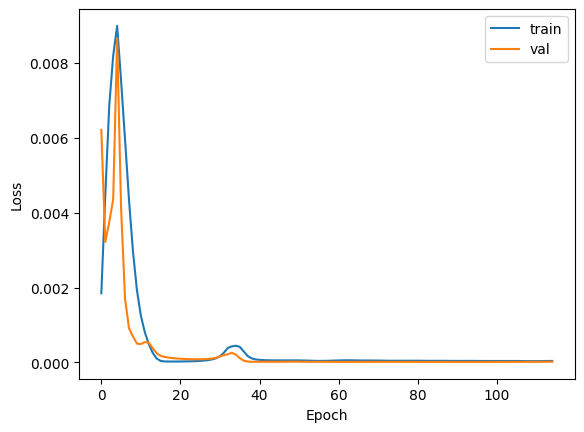

Early stopping at epoch 119
Best validation loss: 0.000015 at epoch 94
Running experiment: HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


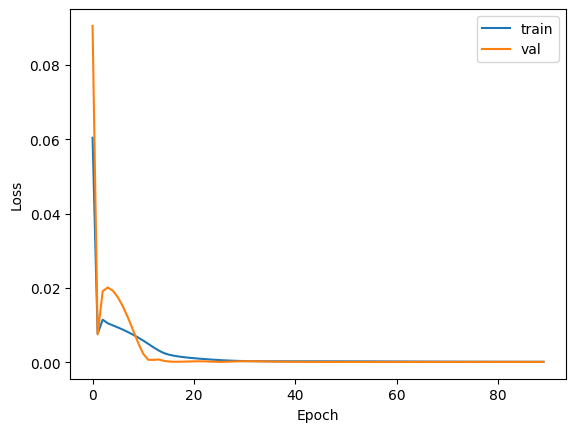

Early stopping at epoch 92
Best validation loss: 0.000054 at epoch 67
Running experiment: HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.1, lr=0.001, optimizer=<class 'torch.optim.adam.Adam'>)


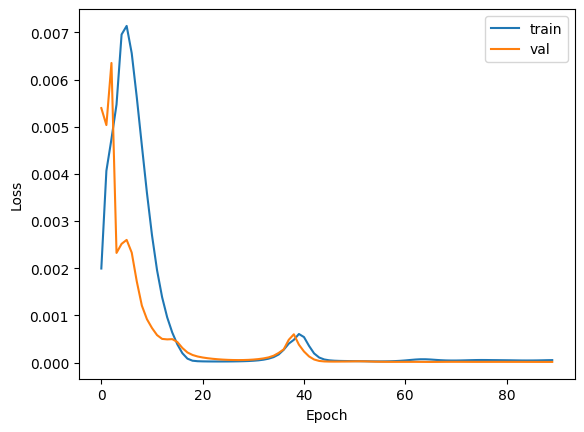

Early stopping at epoch 91
Best validation loss: 0.000015 at epoch 66
Running experiment: HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.1, lr=0.0001, optimizer=<class 'torch.optim.adam.Adam'>)


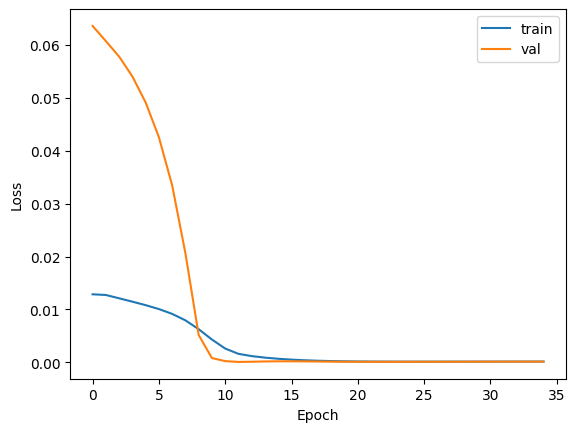

Early stopping at epoch 37
Best validation loss: 0.000080 at epoch 12


In [24]:
exp_runner.run_grid_search()

{'loss': 0.0004981450331886846, 'mae': 51.79301624024915, 'rmse': 65.66197707927697, 'r2': 0.9431271745209066, 'directional_accuracy': 0.3490304709141274, 'naive_rmse': 37.397275446895975, 'n_samples': 723, 'scale': 'unscaled', 'loss_scale': 'scaled'}


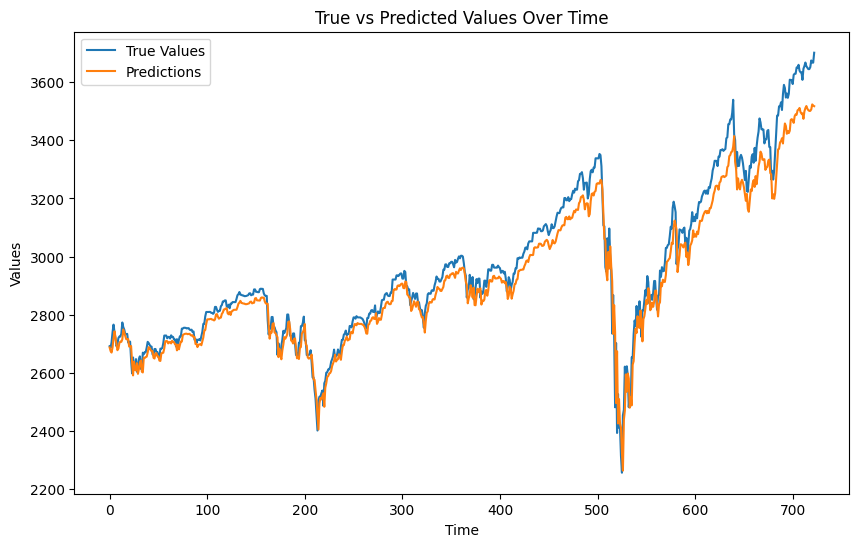

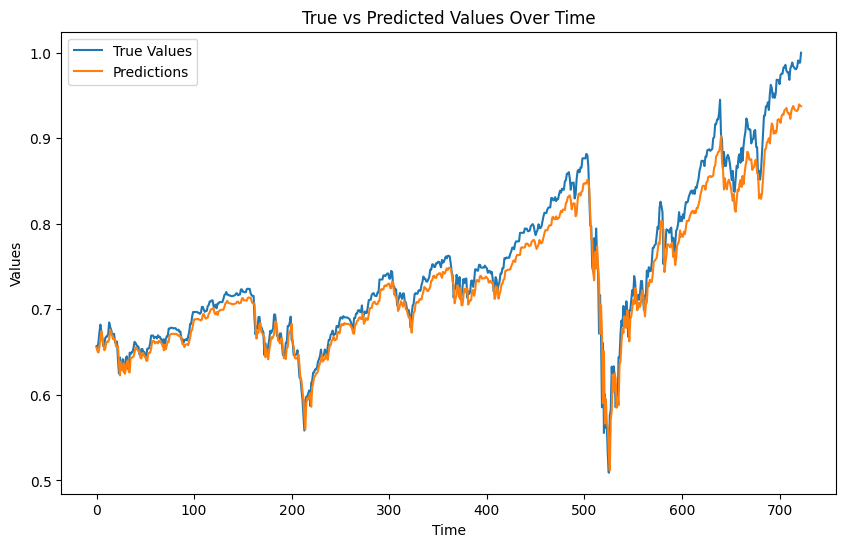

In [25]:
exp_runner.evaluate_best_model()

In [26]:
exp_runner.get_best_hyperparam_config()

HyperparamConfig(features=['Close_SPX'], window_size=30, horizon=1, batch_size=16, patience=10, seed=1, hidden_size=50, num_layers=1, dropout=0.0, lr=0.001, optimizer=<class 'torch.optim.adam.Adam'>)

In [30]:
exp_runner.simulate_trading("2015-01-01", "2015-01-07", 10000, TradingStrategy.prediction_direction())

,date,price,predicted,position,strategy_return,equity
0,2015-01-02,2082.88252,2089.934946,1,-0.013637,9863.627450
1,2015-01-05,2054.47772,2085.775720,1,-0.005713,9807.274776
2,2015-01-06,2042.74012,2059.205877,1,0.006890,9874.848438
3,2015-01-07,2056.81492,2046.454295,-1,0.000000,9874.848438
